# Area Plot Gallery

Area plots visualise distributions over time or across categories using filled bands. They're well suited to retail dashboards where the eye needs to land on *trend shape* and *cumulative size* at the same time, rather than reading individual values.

Area plots excel at:
- **Trend shape**: see whether daily revenue is climbing, plateauing, or rolling over
- **Channel mix over time**: contrast a fast-growing channel against a flat one
- **Region-by-region comparisons**: parallel trends are easy to read as overlaid bands

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import area
from openretailscience.plots.styles.graph_utils import set_axis_shorthand

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each dataset tells a clear retail story so the chart title is true at a glance.

daily_revenue = pd.DataFrame(
    {
        "revenue": [
            45_000,
            52_000,
            48_000,
            61_000,
            67_000,
            58_000,
            63_000,
            71_000,
            68_000,
            75_000,
            82_000,
            79_000,
            85_000,
            88_000,
        ],
    },
    index=pd.date_range("2024-01-01", periods=14, freq="D"),
)

monthly_sales = pd.DataFrame(
    {
        "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
        "sales": [125_000, 145_000, 138_000, 162_000, 175_000, 168_000],
    },
)

category_revenue = pd.DataFrame(
    {
        "week": pd.Categorical(
            [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5],
            ordered=True,
        ),
        "product_category": ["Electronics", "Apparel", "Home"] * 5,
        "revenue": [
            35_000,
            22_000,
            18_000,
            38_000,
            25_000,
            19_000,
            41_000,
            28_000,
            21_000,
            44_000,
            31_000,
            23_000,
            47_000,
            33_000,
            25_000,
        ],
    },
)

channel_revenue = pd.DataFrame(
    {
        "quarter": ["Q1", "Q2", "Q3", "Q4"],
        "Online": [180_000, 210_000, 245_000, 285_000],
        "Stores": [320_000, 315_000, 305_000, 310_000],
        "Wholesale": [95_000, 105_000, 115_000, 108_000],
    },
)

customer_growth = pd.Series(
    [2_500, 2_650, 2_800, 3_100, 3_350, 3_600, 3_800],
    index=pd.CategoricalIndex(range(1, 8), ordered=True),
    name="Active Customers",
)

regional_sales = pd.DataFrame(
    {
        "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
        "North": [85_000, 92_000, 88_000, 95_000, 102_000, 98_000],
        "South": [76_000, 83_000, 79_000, 86_000, 91_000, 87_000],
        "West": [68_000, 74_000, 71_000, 78_000, 83_000, 80_000],
    },
)

## Basic Area Plot

The simplest call: pass a single `value_col` and the DataFrame's index becomes the x-axis. Use this shape when the index already carries the meaning, like a `DatetimeIndex` of trading days. The filled band makes the *direction of travel* easier to read than a thin line.

---

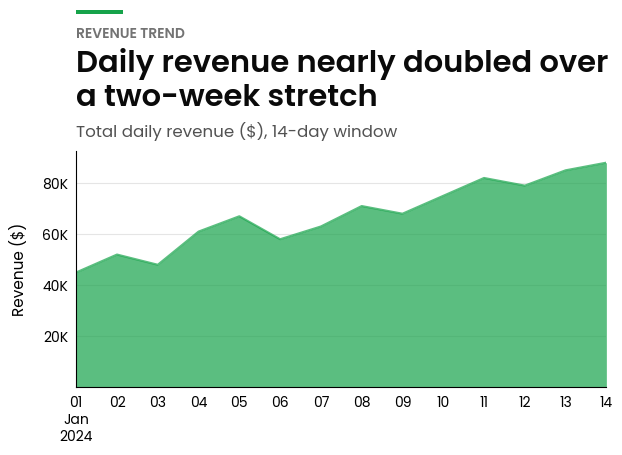

In [ ]:
ax = area.plot(
    daily_revenue,
    value_col="revenue",
    eyebrow="Revenue trend",
    title="Daily revenue nearly doubled over a two-week stretch",
    subtitle="Total daily revenue ($), 14-day window",
    y_label="Revenue ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Using `x_col`

When the x-axis values live in a column rather than the index, point `x_col` at that column. Common when the data comes back from a SQL query that puts the time bucket in its own column instead of the index. Order is preserved as-is, so make sure the column is already sorted the way you want it shown.

---

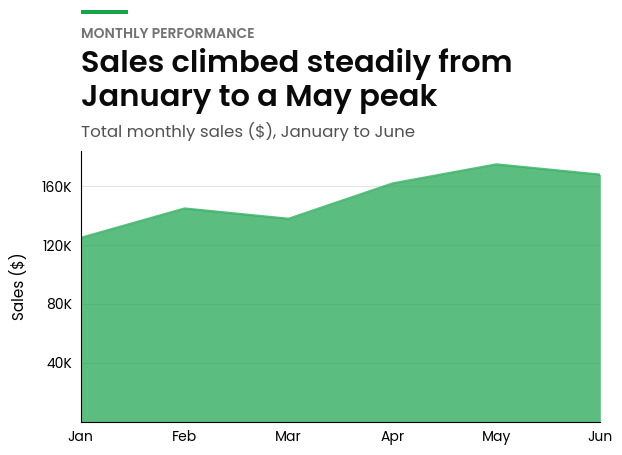

In [ ]:
ax = area.plot(
    monthly_sales,
    x_col="month",
    value_col="sales",
    eyebrow="Monthly performance",
    title="Sales climbed steadily from January to a May peak",
    subtitle="Total monthly sales ($), January to June",
    y_label="Sales ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Multiple Areas with `group_col`

Pass `group_col` to draw one band per category from a *long-format* DataFrame. The function pivots the data internally and assigns a colour per group.

---

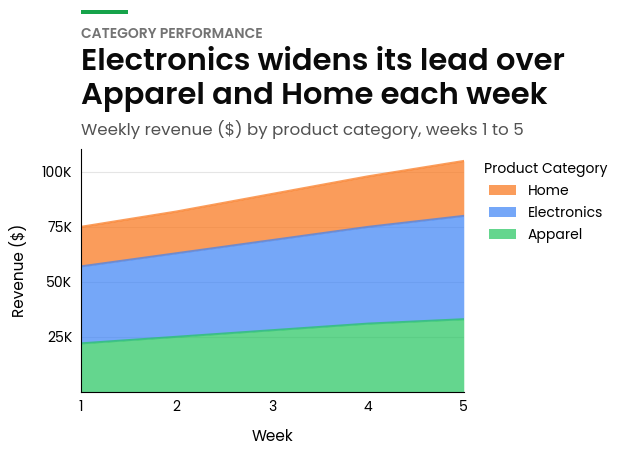

In [ ]:
ax = area.plot(
    category_revenue,
    x_col="week",
    value_col="revenue",
    group_col="product_category",
    eyebrow="Category performance",
    title="Electronics widens its lead over Apparel and Home each week",
    subtitle="Weekly revenue ($) by product category, weeks 1 to 5",
    x_label="Week",
    y_label="Revenue ($)",
    legend_title="Product Category",
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Multiple Value Columns

If the data is already in *wide format* (one column per series), pass a list to `value_col` instead of using `group_col`. The two are mutually exclusive: passing both raises `ValueError` because the function wouldn't know how to disambiguate. Use this shape when the upstream query gives you each series as its own column.

---

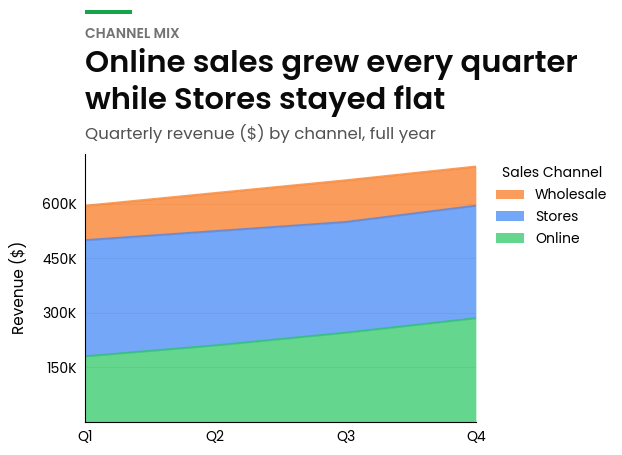

In [ ]:
ax = area.plot(
    channel_revenue,
    x_col="quarter",
    value_col=["Online", "Stores", "Wholesale"],
    eyebrow="Channel mix",
    title="Online sales grew every quarter while Stores stayed flat",
    subtitle="Quarterly revenue ($) by channel, full year",
    y_label="Revenue ($)",
    legend_title="Sales Channel",
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Plotting a Pandas Series

A `Series` works directly: the function converts it to a single-column DataFrame and uses the series name as the value column. Useful when the upstream computation (a `groupby().sum()` for example) already returns a Series and you don't want to wrap it just to plot.

---

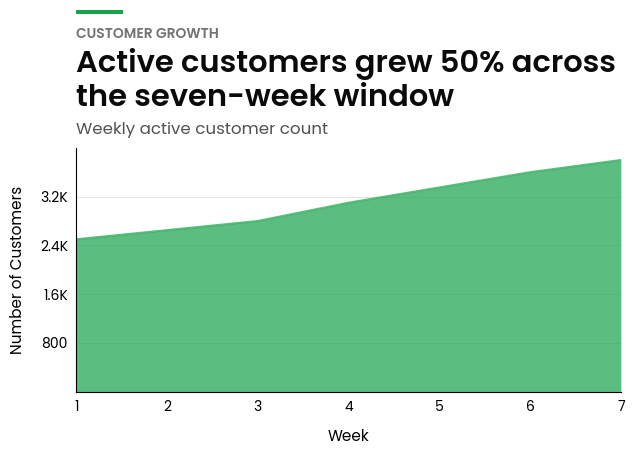

In [ ]:
ax = area.plot(
    customer_growth,
    value_col="Active Customers",
    eyebrow="Customer growth",
    title="Active customers grew 50% across the seven-week window",
    subtitle="Weekly active customer count",
    x_label="Week",
    y_label="Number of Customers",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Advanced Styling Options

Two knobs worth knowing: `source_text` adds a small attribution at the bottom of the chart for export-ready images, and `move_legend_outside=True` lifts the legend to the right edge so it never sits on top of the data.

---

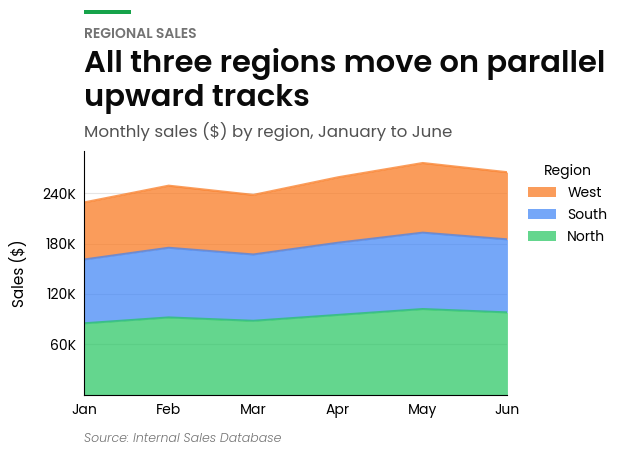

In [ ]:
ax = area.plot(
    regional_sales,
    x_col="month",
    value_col=["North", "South", "West"],
    eyebrow="Regional sales",
    title="All three regions move on parallel upward tracks",
    subtitle="Monthly sales ($) by region, January to June",
    y_label="Sales ($)",
    legend_title="Region",
    move_legend_outside=True,
    source_text="Source: Internal Sales Database",
)
set_axis_shorthand(ax.yaxis)
plt.show()

## End-of-Line Legend

Pass `legend_style="end_of_line"` to suppress the boxed legend and place a coloured series label at the right end of each band instead. The label sits next to the data it describes, so the reader doesn't need to bounce back and forth between a legend swatch and a band. Works best with three to five series, more than that and the labels start to crowd each other.

---

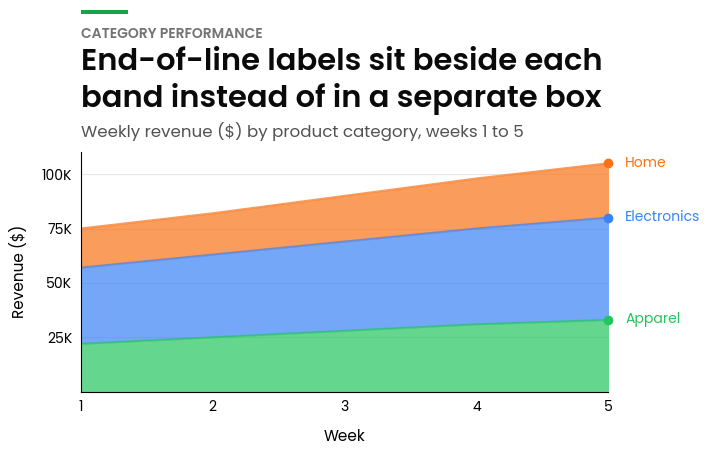

In [ ]:
ax = area.plot(
    category_revenue,
    x_col="week",
    value_col="revenue",
    group_col="product_category",
    legend_style="end_of_line",
    eyebrow="Category performance",
    title="End-of-line labels sit beside each band instead of in a separate box",
    subtitle="Weekly revenue ($) by product category, weeks 1 to 5",
    x_label="Week",
    y_label="Revenue ($)",
)
set_axis_shorthand(ax.yaxis)
plt.show()